In [2]:
import matplotlib.pyplot as plt
%ls log
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"


ls: cannot access 'log': No such file or directory


In [3]:
import json
import glob
import pandas as pd 
df = pd.read_csv("/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/sparse/mult/tests/log.csv")
df

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep
0,SparseUT,500x500,0,0.021067,21.109760,0
1,SparseUT,500x500,0,0.002449,5.882880,1
2,SparseUT,500x500,0,0.002385,5.828608,2
3,SparseUT,500x500,0,0.002418,5.870592,3
4,SparseUT,500x500,0,0.002414,5.828608,4
...,...,...,...,...,...,...
1765,SparseTorch,10000x10000,99,0.233107,233.891846,5
1766,SparseTorch,10000x10000,99,0.232968,233.766907,6
1767,SparseTorch,10000x10000,99,0.233037,233.839615,7
1768,SparseTorch,10000x10000,99,0.233137,233.947144,8


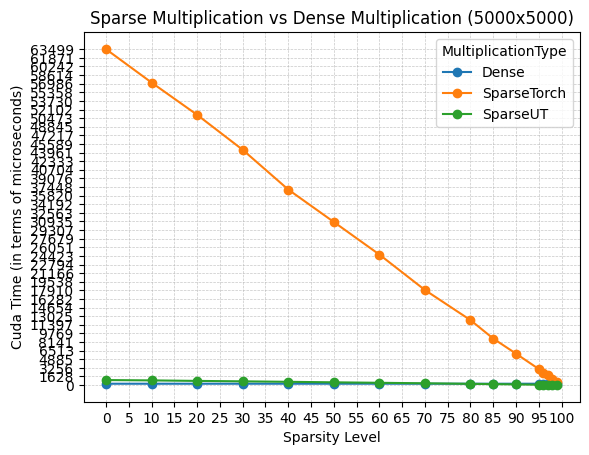

In [4]:
import numpy as np
dense_level = "5000x5000"
df_dlvl = df[df.dense_level == dense_level]
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
max_avg_s = 0
# Group by the 'category' column and plot each group
for category, group in df_dlvl.groupby('isSparse'):
    avg_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].mean()*10
    std_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].std()*10
    sparsity_level = group.groupby('sparsity_level')['sparsity_level'].first()
    max_avg_s = max(max_avg_s, avg_per_sparsity.max())
    plt.plot(sparsity_level, avg_per_sparsity,marker='o', linestyle='-', label=category)
    plt.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, avg_per_sparsity + std_per_sparsity, alpha=0.2)
plt.xticks(list(range(0, 101, 5)))
plt.yticks(np.linspace(0, max_avg_s, 40))



plt.rcParams['figure.figsize']=(8,8)
# Add title and labels
plt.title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
plt.xlabel('Sparsity Level')
plt.ylabel('Cuda Time (in terms of microseconds)')

# Show legend
plt.legend(title='MultiplicationType')

# Display the plot
plt.show()

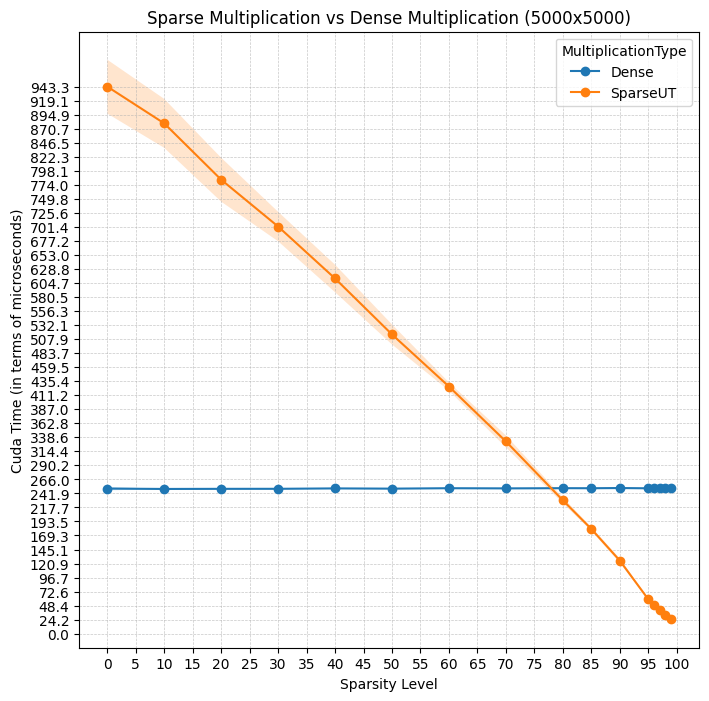

In [6]:
import numpy as np
dense_level = "5000x5000"
df_dlvl = df[df.dense_level == dense_level]
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
max_avg_s = 0
# Group by the 'category' column and plot each group
df_dlvl=df_dlvl[df_dlvl.isSparse != 'SparseTorch']
for category, group in df_dlvl.groupby('isSparse'):
    avg_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].mean()*10
    std_per_sparsity = group.groupby('sparsity_level')['cuda_elapsed_time'].std()*10
    sparsity_level = group.groupby('sparsity_level')['sparsity_level'].first()
    max_avg_s = max(max_avg_s, avg_per_sparsity.max())
    plt.plot(sparsity_level, avg_per_sparsity,marker='o', linestyle='-', label=category)
    plt.fill_between(sparsity_level, avg_per_sparsity - std_per_sparsity, avg_per_sparsity + std_per_sparsity, alpha=0.2)
plt.xticks(list(range(0, 101, 5)))
plt.yticks(np.linspace(0, max_avg_s, 40))



plt.rcParams['figure.figsize']=(8,8)
# Add title and labels
plt.title(f'Sparse Multiplication vs Dense Multiplication ({dense_level})')
plt.xlabel('Sparsity Level')
plt.ylabel('Cuda Time (in terms of microseconds)')

# Show legend
plt.legend(title='MultiplicationType')

# Display the plot
plt.show()